In [1]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

# Импорт

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Загрузка данных

In [9]:
dataframe = pd.read_csv("sonar.csv", header=None)
print(dataframe.head())

       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58      59  60  
0  0.0090  0.0032   R  
1  0.0052  0.0044   R  
2  0.0095  0.0078   

# Предобработка данных


In [11]:
X = dataset[:, 0:60].astype(float)
Y = dataset[:, 60]

encoder = LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)

X_train, X_test, y_train, y_test = train_test_split(
    X, encoded_Y, test_size=0.2, random_state=42, stratify=encoded_Y
)

# Исследование данных

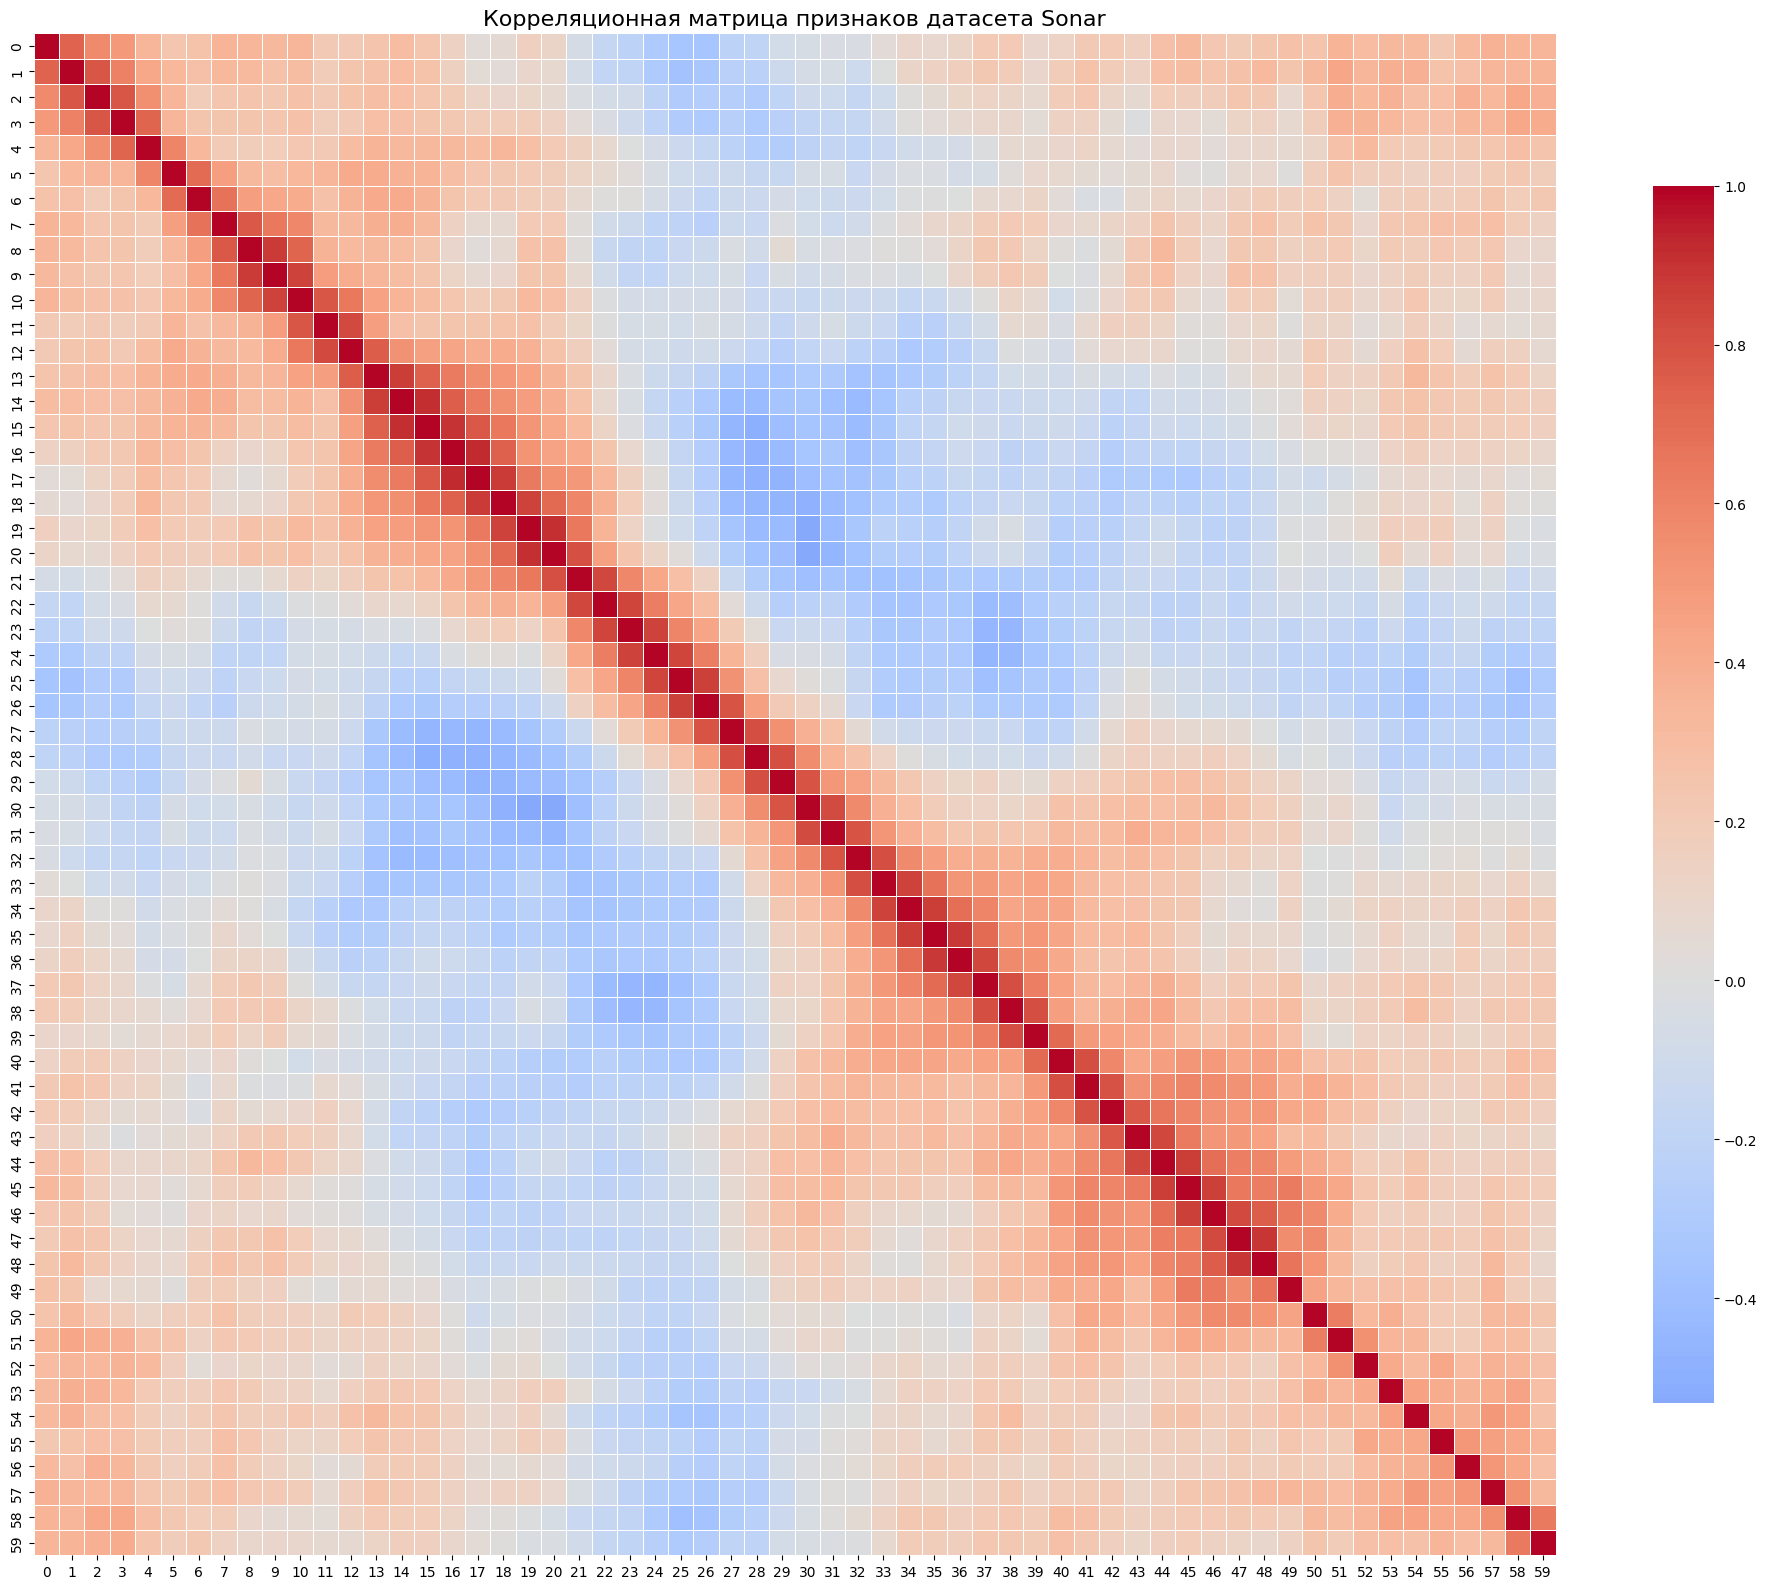

In [34]:
X = dataframe.iloc[:, :-1]
corr_matrix = X.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков датасета Sonar', fontsize=16)
plt.tight_layout()
plt.show()

# Генерация модели


In [25]:
def create_model(architecture, input_dim=60):
    model = Sequential()
    model.add(Dense(architecture[0], input_dim=input_dim, activation='relu'))
    for units in architecture[1:]:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Сравнение архитектур

In [27]:
architectures = [
    [15],        # очень маленькая однослойная
    [30],       # средняя однослойная
    [60],       # базовая однослойная
    [120],      # большая однослойная
    [60, 30],   # двухслойная: сжатие 60-30
    [60, 15],   # двухслойная: сильное сжатие 60-15
    [30, 15],   # двухслойная: уже сжато 30-15
    [16, 8]     # двухслойная: маленькая 16-8
]
architecture_results = []

for arch in architectures:
    print(f"\nОбучение архитектуры: {arch}")
    model = create_model(arch)
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=10,
        validation_split=0.1,
        verbose=0
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    architecture_results.append({
        'architecture': arch,
        'final_train_acc': history.history['accuracy'][-1],
        'final_val_acc': history.history['val_accuracy'][-1],
        'test_acc': test_acc,
        'history': history
    })
    print(f"\tТочность на валидации: {history.history['val_accuracy'][-1]:.4f}")
    print(f"\tТочность на тесте: {test_acc:.4f}")


Обучение архитектуры: [15]
	Точность на валидации: 0.8824
	Точность на тесте: 0.8095

Обучение архитектуры: [30]
	Точность на валидации: 0.8824
	Точность на тесте: 0.8333

Обучение архитектуры: [60]
	Точность на валидации: 0.8824
	Точность на тесте: 0.8333

Обучение архитектуры: [120]
	Точность на валидации: 0.9412
	Точность на тесте: 0.7857

Обучение архитектуры: [60, 30]
	Точность на валидации: 0.9412
	Точность на тесте: 0.8810

Обучение архитектуры: [60, 15]
	Точность на валидации: 0.9412
	Точность на тесте: 0.8571

Обучение архитектуры: [30, 15]
	Точность на валидации: 0.8235
	Точность на тесте: 0.8095

Обучение архитектуры: [16, 8]
	Точность на валидации: 0.9412
	Точность на тесте: 0.7619


## Графики потерь и точности

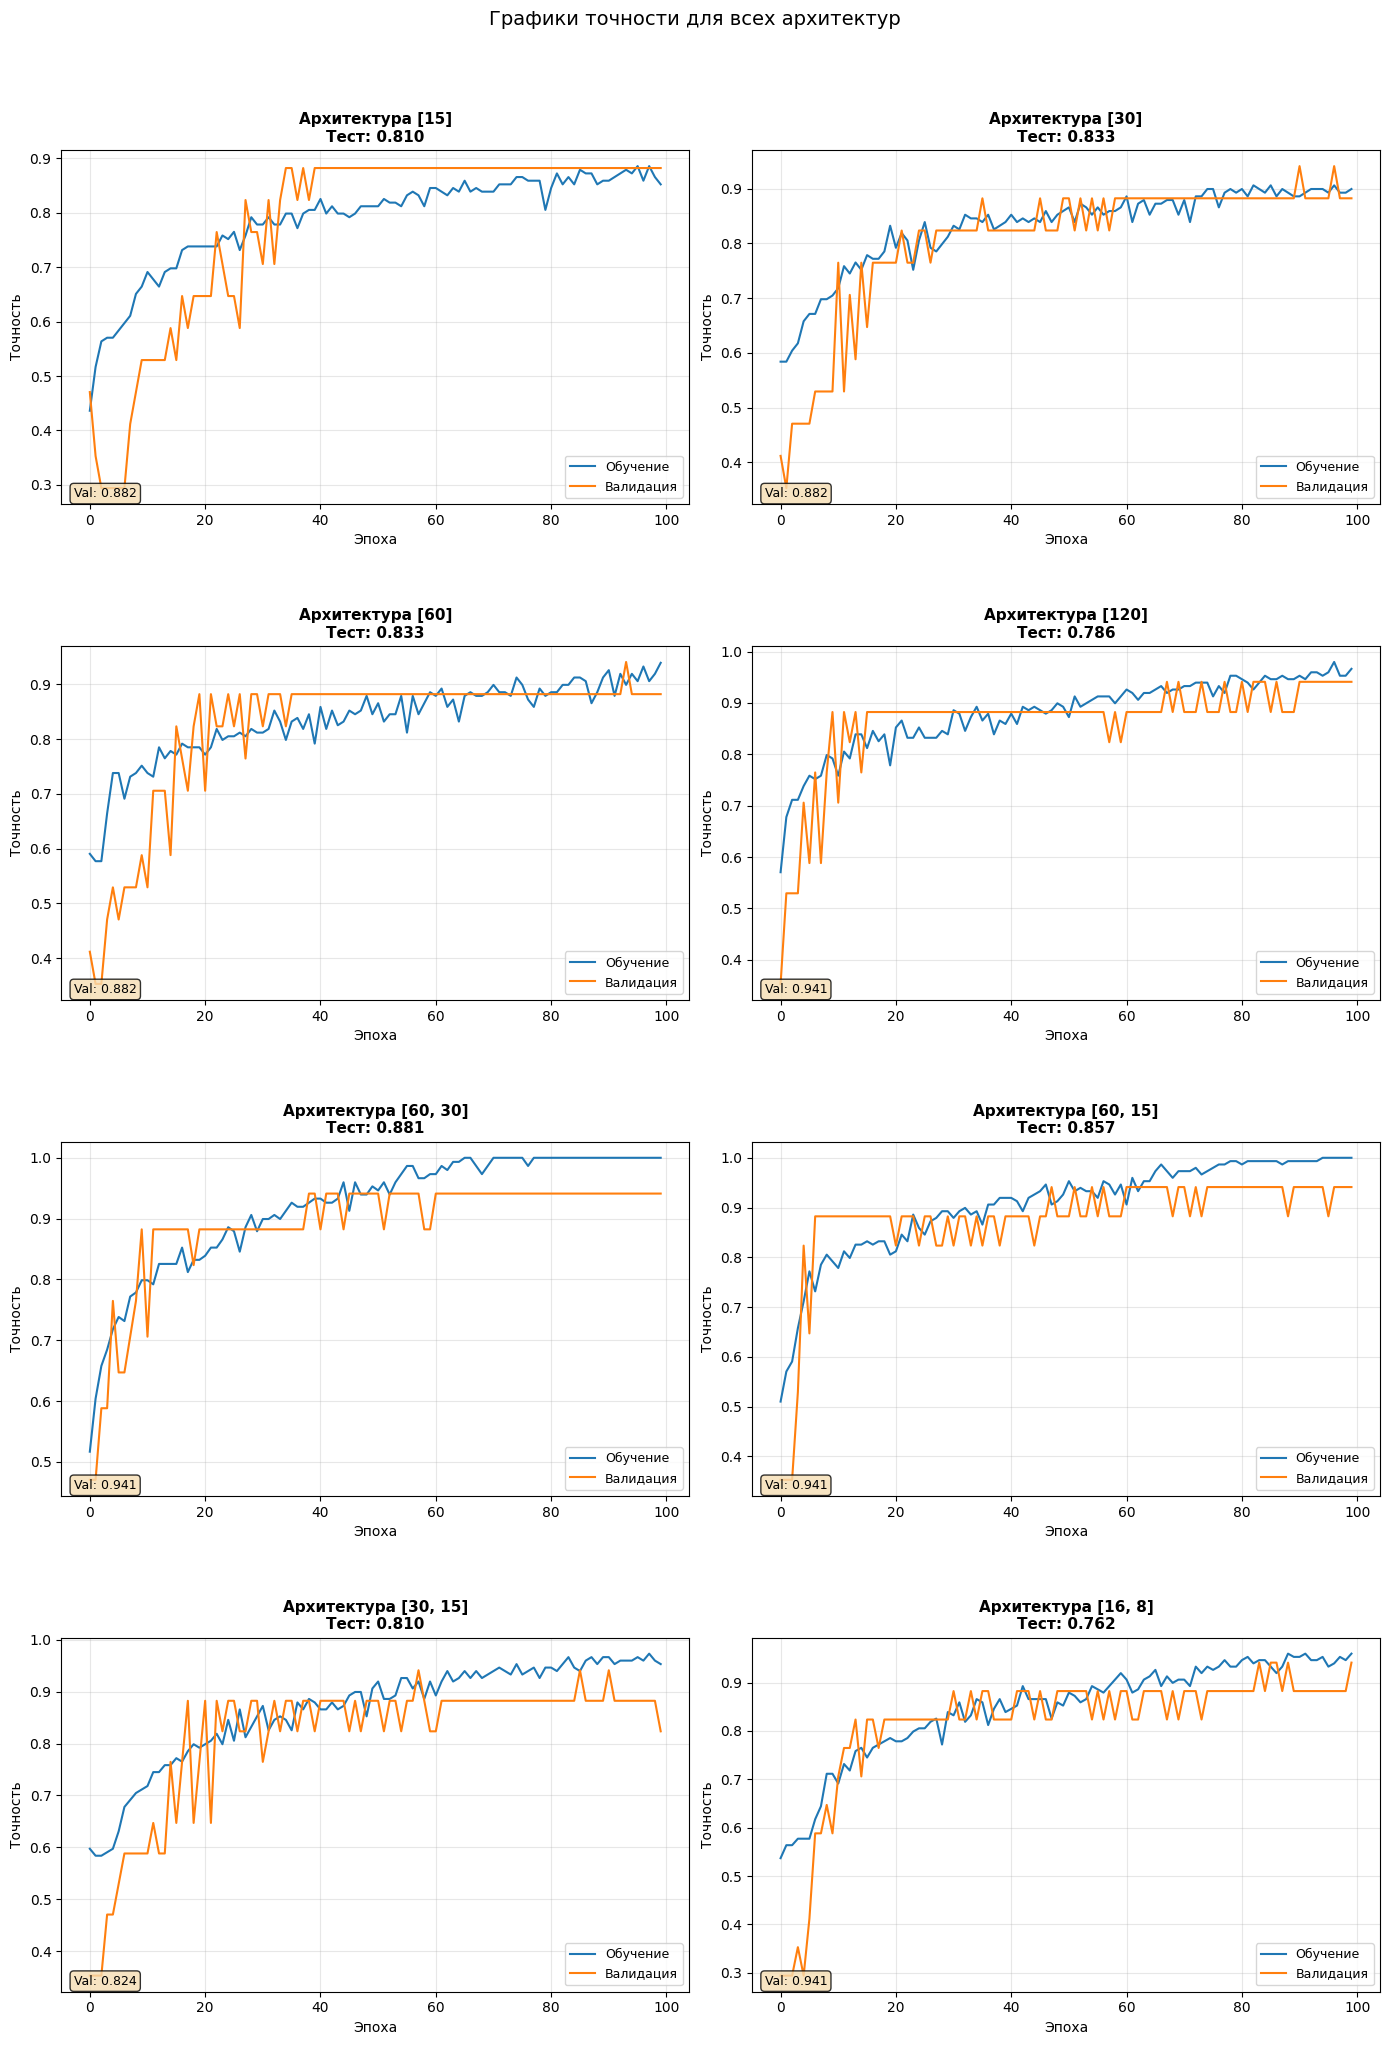

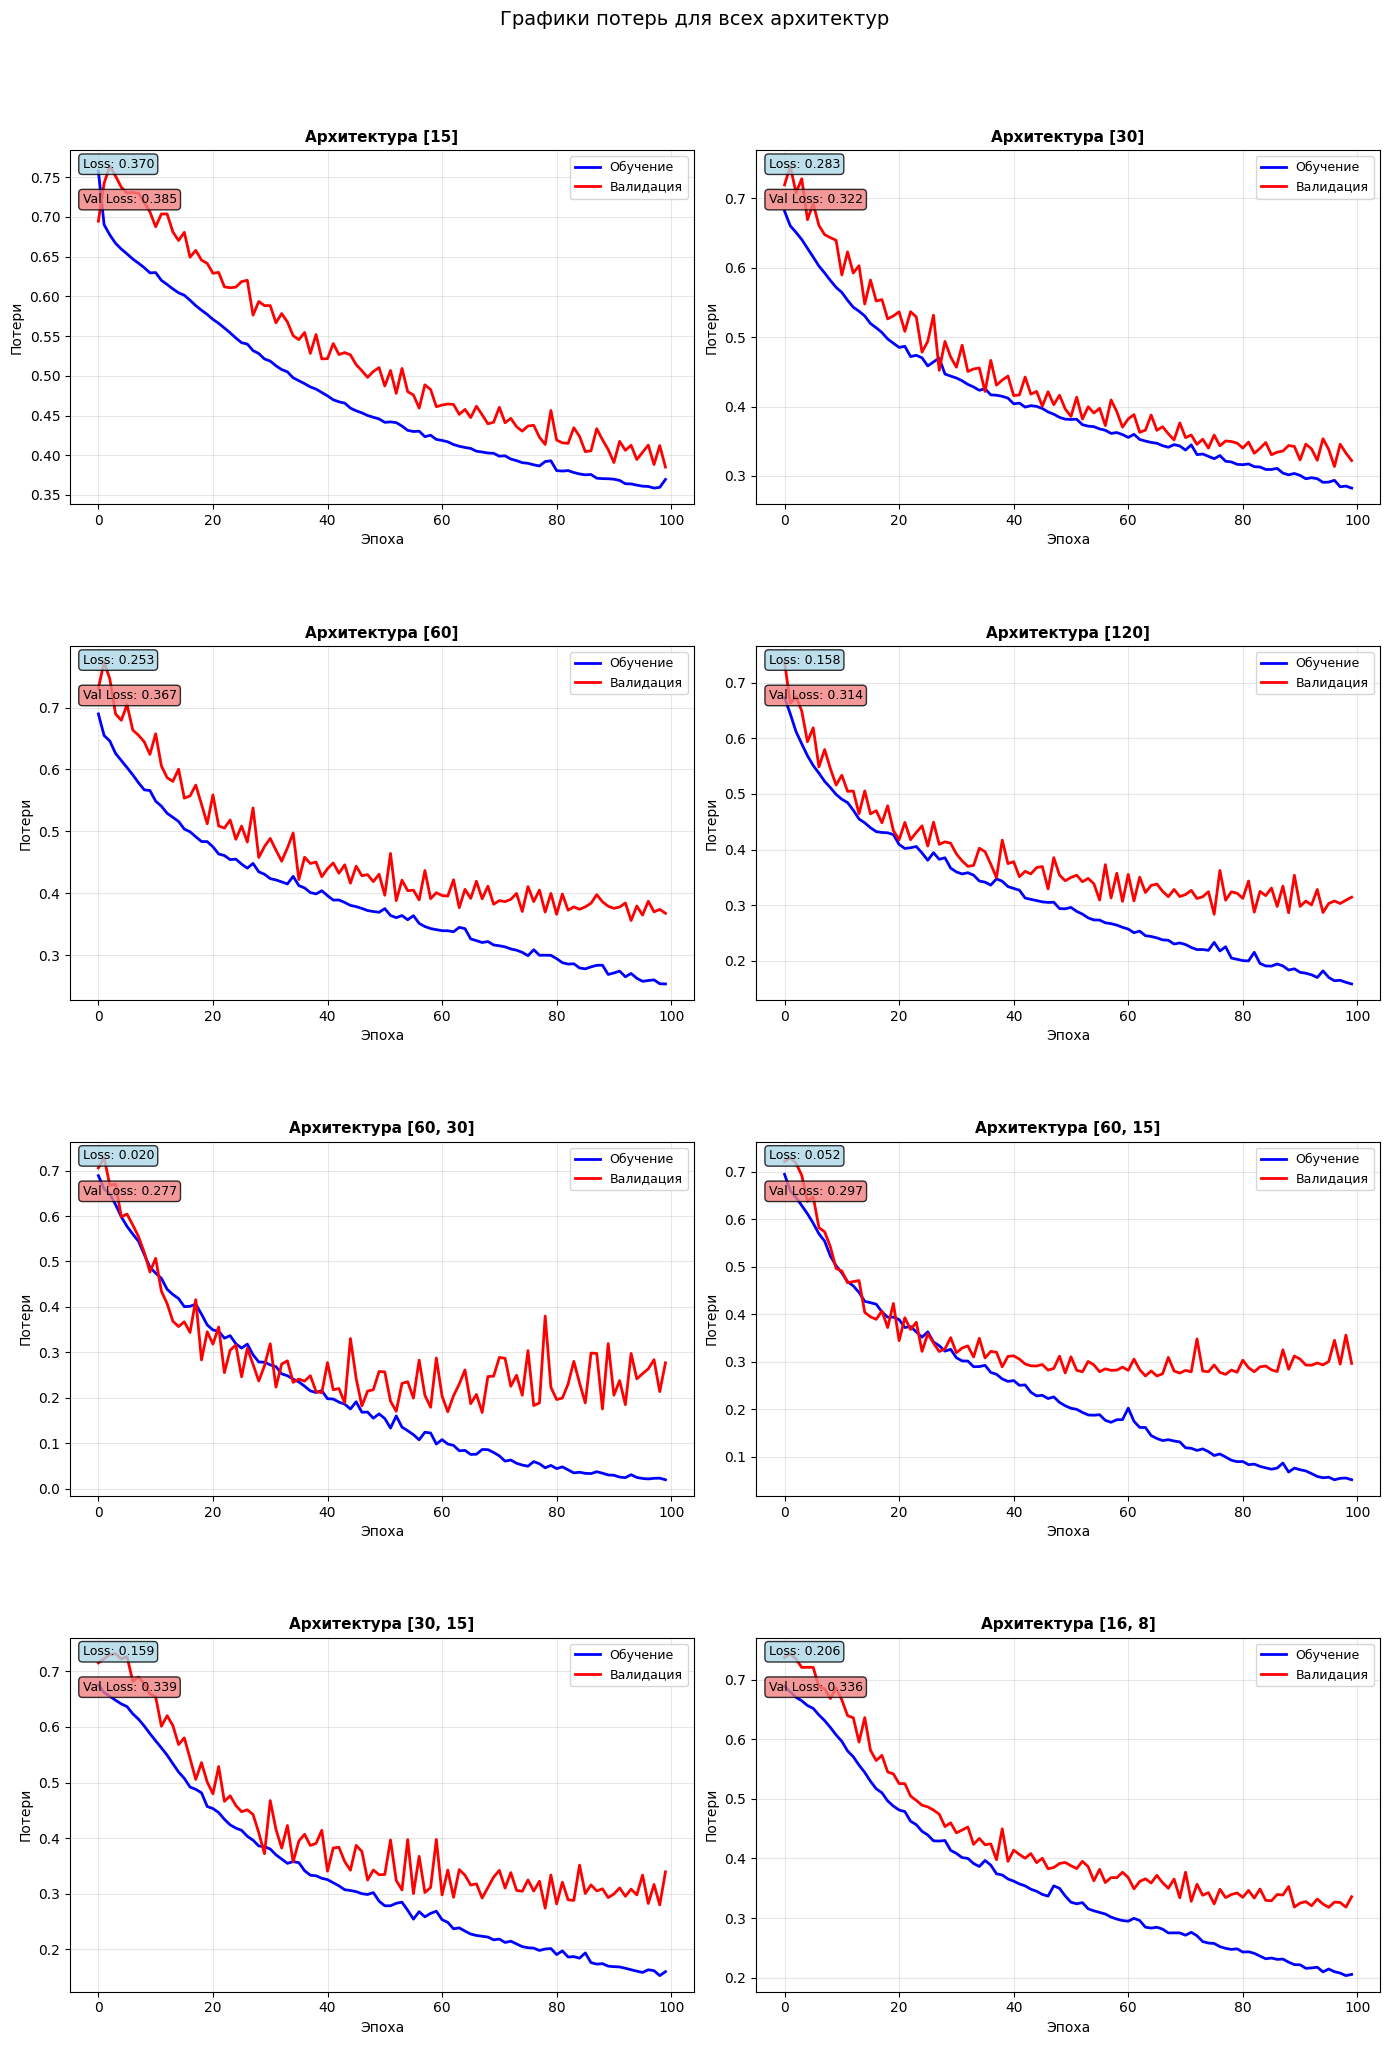

In [28]:
def plot_accuracy_grid(architecture_results, architectures):
    n = len(architectures)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    fig.suptitle('Графики точности для всех архитектур', fontsize=14, y=1.02)
    axes_flat = axes.flatten() if n > 1 else [axes]

    for idx, arch in enumerate(architectures):
        result = next(r for r in architecture_results if r['architecture'] == arch)
        history = result['history']
        ax = axes_flat[idx]
        ax.plot(history.history['accuracy'], label='Обучение')
        ax.plot(history.history['val_accuracy'], label='Валидация')
        ax.set_xlabel('Эпоха', fontsize=10)
        ax.set_ylabel('Точность', fontsize=10)
        ax.set_title(f'Архитектура {arch}\nТест: {result["test_acc"]:.3f}',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.02, f'Val: {result["final_val_acc"]:.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Скрыть неиспользуемые подграфики
    for j in range(len(architectures), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.4, wspace=0.1)
    plt.show()


def plot_loss_grid(architecture_results, architectures):
    n = len(architectures)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    fig.suptitle('Графики потерь для всех архитектур', fontsize=14, y=1.02)
    axes_flat = axes.flatten() if n > 1 else [axes]

    for idx, arch in enumerate(architectures):
        result = next(r for r in architecture_results if r['architecture'] == arch)
        history = result['history']
        ax = axes_flat[idx]
        ax.plot(history.history['loss'], 'b-', linewidth=2, label='Обучение')
        ax.plot(history.history['val_loss'], 'r-', linewidth=2, label='Валидация')
        ax.set_xlabel('Эпоха', fontsize=10)
        ax.set_ylabel('Потери', fontsize=10)
        ax.set_title(f'Архитектура {arch}', fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.95, f'Loss: {history.history["loss"][-1]:.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        ax.text(0.02, 0.85, f'Val Loss: {history.history["val_loss"][-1]:.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

    for j in range(len(architectures), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.4, wspace=0.1)
    plt.show()

plot_accuracy_grid(architecture_results, architectures)
plot_loss_grid(architecture_results, architectures)